In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Стили графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


  ЗАДАНИЕ 1: Временная диаграмма + тестовые значения M/M/1/2
  λ = 0.32 [1/сек],  μ = 0.4 [1/сек]

  ──────────────────────────────────────────────────
  ТЕСТОВЫЕ ЗНАЧЕНИЯ:
  ──────────────────────────────────────────────────
  Общее число заявок (Tmod):            6
  Число обработанных:                    4
  Число отказов:                         2
  Относит. пропускная сп-ть Q:           0.6667
  Вероятность отказа Pf:                  0.3333
  Время наблюдения:                      12.5 сек
  Время работы процессора:               11.0 сек
  Время простоя процессора:              1.5 сек
  Вероятность загрузки процессора:        0.8800
  Вероятность простоя процессора:         0.1200


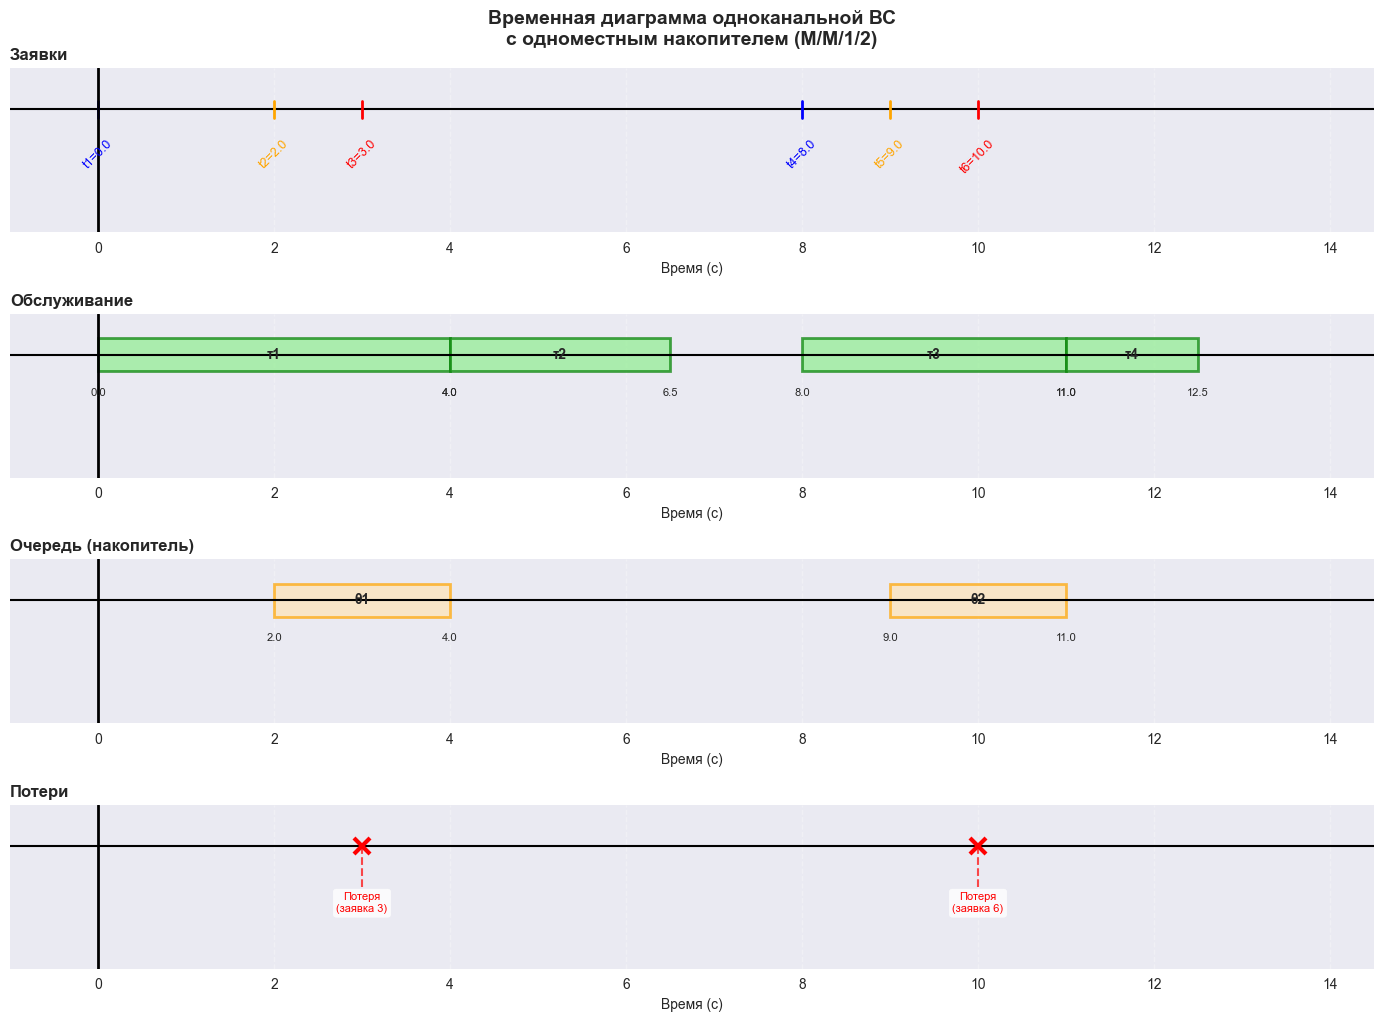


  Задание 1 — Аналитические значения (ТМО)
  ρ = λ/μ                                   = 0.800000
  P₀ (простой системы)                      = 0.409836
  P₁ (сервер занят, очередь пуста)           = 0.327869
  P₂ = Pf (отказ)                           = 0.262295
  Q  (относит. пропускная способность)       = 0.737705
  A  (абсолют. пропускная способность)       = 0.236066
  k  (коэфф. загрузки)                       = 0.590164
  L  (среднее число в очереди)                = 0.262295
  tr (среднее время ожидания в очереди)       = 0.819672 сек

  ЗАДАНИЕ 2: Имитационное моделирование M/M/1/2  (T = 1000 сек)

  Результаты моделирования M/M/1/2
  (λ=0.32, μ=0.4, T=1000 сек)
  Поступило заявок (Tmod):                   313
  Число обработанных (завершённых):           231
  Число отказов:                              81
  Относит. пропускная способность (Q):        0.7412
  Вероятность отказа (Pf):                    0.2588
  Время работы процессора:                    625.91 сек
  Время

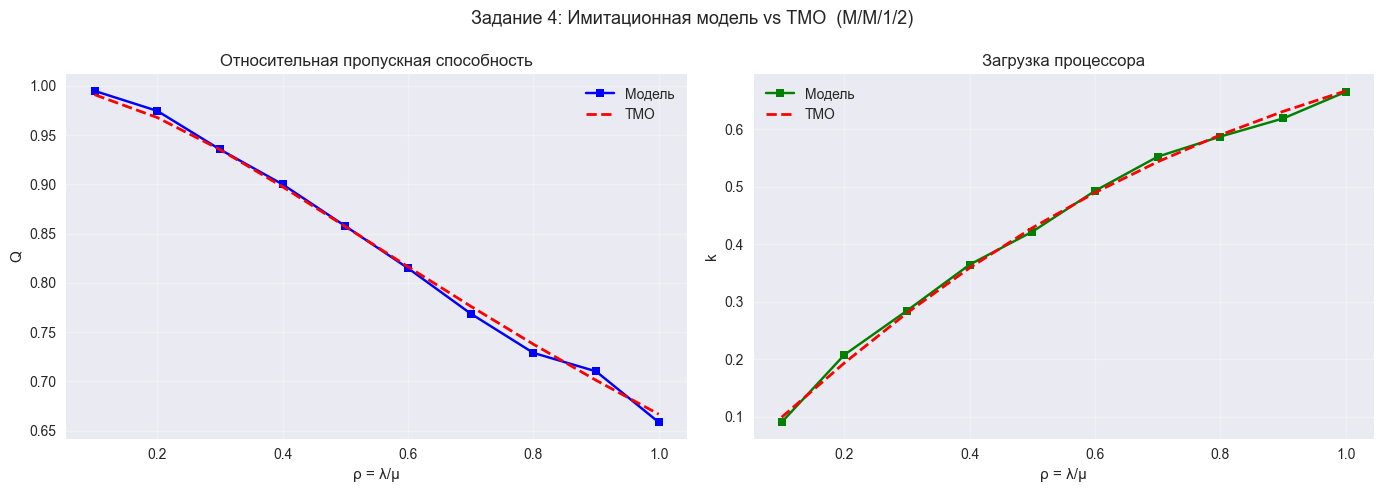


  ЗАДАНИЕ 5: Сравнение Q для M/M/1/1 (отказы) и M/M/1/2 (накопитель)

  ρ       Q (отказы)      Q (накопитель)    Выигрыш   
  ----------------------------------------------------
  0.2     0.8333          0.9677            0.1344    
  0.4     0.7143          0.8974            0.1832    
  0.6     0.6250          0.8163            0.1913    
  0.8     0.5556          0.7377            0.1821    
  1.0     0.5000          0.6667            0.1667    


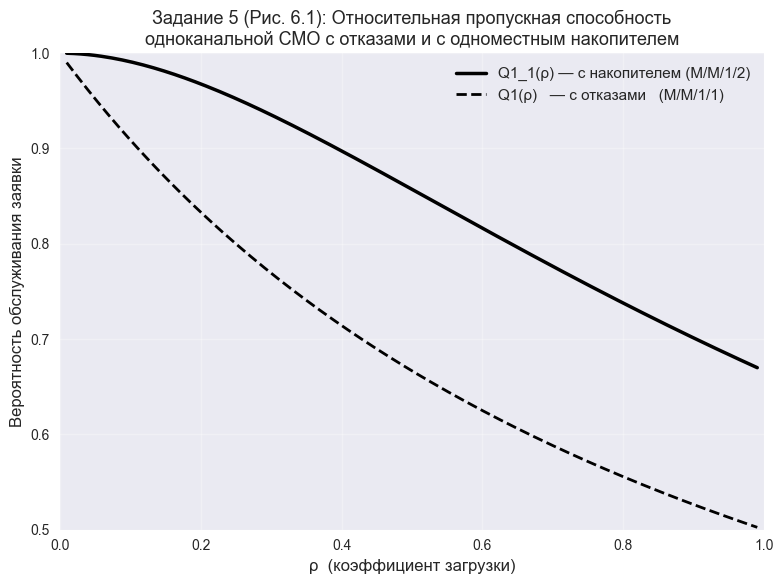


  ЗАДАНИЕ 6: Эффективность (стоимость прибыли) E
  Параметры: μ = 0.4,  c1 = 1.0,  qf = 0.15,  qr = 0.01

  λ       ρ       E_1 (отк.)    E1_1 (нак.)   ΔE        
  ------------------------------------------------------
  0.04    0.10    0.0358        0.0373        0.0015    
  0.08    0.20    0.0647        0.0730        0.0083    
  0.16    0.40    0.1074        0.1347        0.0273    
  0.24    0.60    0.1365        0.1817        0.0452    
  0.32    0.80    0.1564        0.2153        0.0588    
  0.40    1.00    0.1700        0.2383        0.0683    
  0.60    1.50    0.1860        0.2653        0.0793    
  0.80    2.00    0.1867        0.2671        0.0805    


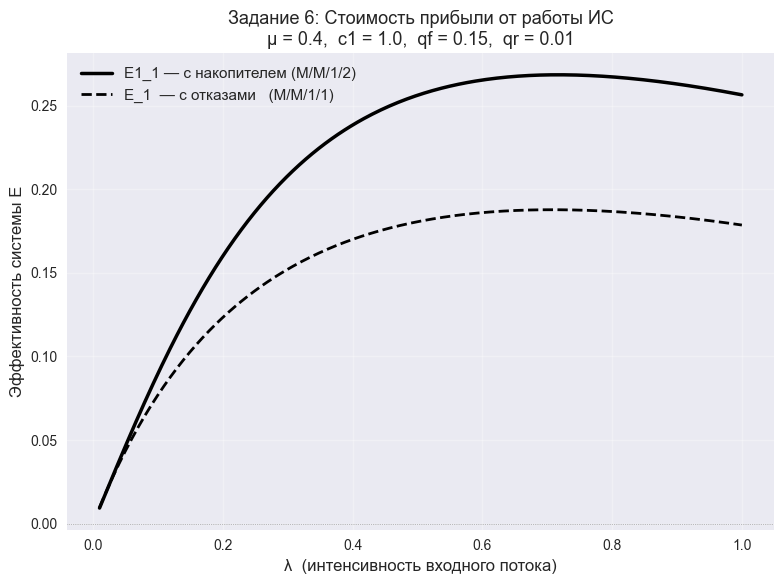

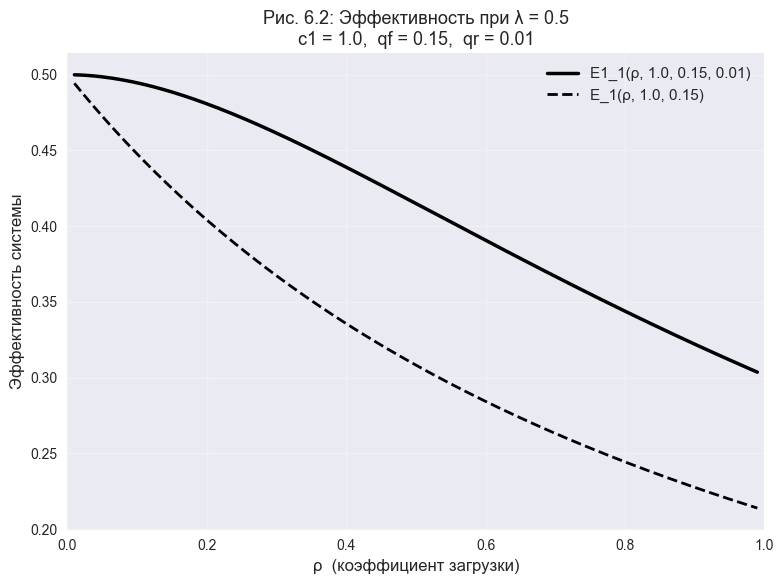

In [2]:
from matplotlib import patches
import numpy as np
import heapq
import matplotlib.pyplot as plt



def trace_mm12_deterministic(arrival_times, service_durations):
    """
    Детерминированная трассировка M/M/1/2 с фиксированными временами.
    service_durations — длительности обслуживания для ПРИНЯТЫХ заявок
    (в порядке принятия).
    """
    events = []
    for i, t in enumerate(arrival_times):
        heapq.heappush(events, (t, 0, i))   # (время, тип=0 приход, индекс)

    server_busy = False
    buffer = None  # (время_прихода, индекс_заявки, длительность_обсл.)

    processing_times = []   # (start, end, request_index)
    queue_times = []        # (enter, leave, request_index)
    loss_times = []         # (time, request_index)

    svc_idx = 0

    while events:
        t, etype, idx = heapq.heappop(events)

        if etype == 0:  # Приход
            if not server_busy:
                server_busy = True
                dur = service_durations[svc_idx]; svc_idx += 1
                processing_times.append((t, t + dur, idx))
                heapq.heappush(events, (t + dur, 1, idx))
            elif buffer is None:
                dur = service_durations[svc_idx]; svc_idx += 1
                buffer = (t, idx, dur)
            else:
                loss_times.append((t, idx))

        elif etype == 1:  # Конец обслуживания
            if buffer is not None:
                buf_arr, buf_idx, buf_dur = buffer
                queue_times.append((buf_arr, t, buf_idx))
                processing_times.append((t, t + buf_dur, buf_idx))
                heapq.heappush(events, (t + buf_dur, 1, buf_idx))
                buffer = None
            else:
                server_busy = False

    return processing_times, queue_times, loss_times



def create_timing_diagram_buffer(processing_times, queue_times,
                                  loss_times, arrival_times):
    """
    Временная диаграмма одноканальной ВС с одноместным накопителем.
    4 линии: Заявки · Обслуживание · Очередь · Потери.
    """
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        4, 1, figsize=(14, 10),
        gridspec_kw={'height_ratios': [1, 1, 1, 1]})

    # --- Границы ---
    all_t = list(arrival_times)
    for s, e, _ in processing_times:
        all_t.extend([s, e])
    for s, e, _ in queue_times:
        all_t.extend([s, e])
    for t, _ in loss_times:
        all_t.append(t)
    min_t = min(0, min(all_t) - 1)
    max_t = max(all_t) + 2

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlim(min_t, max_t)
        ax.set_ylim(-0.5, 1.5)
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(True, axis='x', alpha=0.3, linestyle='--')

    # Классификация заявок
    queued_set = {idx for _, _, idx in queue_times}
    lost_set   = {idx for _, idx   in loss_times}

    # ---------- 1. Заявки ----------
    ax1.set_title('Заявки', loc='left', fontweight='bold', fontsize=12)
    ax1.axhline(y=1, color='black', linewidth=1.5)
    for i, t in enumerate(arrival_times):
        color = 'red' if i in lost_set else ('orange' if i in queued_set else 'blue')
        ax1.plot([t, t], [0.9, 1.1], color=color, linewidth=2)
        ax1.text(t, 0.65, f't{i+1}={t:.1f}', ha='center', va='top',
                 fontsize=9, rotation=45, color=color)

    # ---------- 2. Обслуживание ----------
    ax2.set_title('Обслуживание', loc='left', fontweight='bold', fontsize=12)
    ax2.axhline(y=1, color='black', linewidth=1.5)
    for i, (s, e, idx) in enumerate(processing_times):
        rect = patches.Rectangle((s, 0.8), e - s, 0.4, linewidth=2,
                                 edgecolor='green', facecolor='lightgreen', alpha=0.7)
        ax2.add_patch(rect)
        ax2.text((s + e) / 2, 1.0, f'τ{i+1}', ha='center', va='center',
                 fontsize=10, fontweight='bold')
        ax2.text(s, 0.6, f'{s:.1f}', ha='center', va='top', fontsize=8)
        ax2.text(e, 0.6, f'{e:.1f}', ha='center', va='top', fontsize=8)

    # ---------- 3. Очередь (накопитель) ----------
    ax3.set_title('Очередь (накопитель)', loc='left', fontweight='bold', fontsize=12)
    ax3.axhline(y=1, color='black', linewidth=1.5)
    for i, (s, e, idx) in enumerate(queue_times):
        rect = patches.Rectangle((s, 0.8), e - s, 0.4, linewidth=2,
                                 edgecolor='orange', facecolor='moccasin', alpha=0.7)
        ax3.add_patch(rect)
        ax3.text((s + e) / 2, 1.0, f'θ{i+1}', ha='center', va='center',
                 fontsize=10, fontweight='bold')
        ax3.text(s, 0.6, f'{s:.1f}', ha='center', va='top', fontsize=8)
        ax3.text(e, 0.6, f'{e:.1f}', ha='center', va='top', fontsize=8)
    if not queue_times:
        ax3.text(max_t / 2, 1.0, '(пусто)', ha='center', fontsize=11, color='gray')

    # ---------- 4. Потери ----------
    ax4.set_title('Потери', loc='left', fontweight='bold', fontsize=12)
    ax4.axhline(y=1, color='black', linewidth=1.5)
    for lt, idx in loss_times:
        ax4.plot(lt, 1.0, 'rx', markersize=12, markeredgewidth=3)
        ax4.plot([lt, lt], [0.5, 1.0], 'r--', linewidth=1.5, alpha=0.7)
        ax4.text(lt, 0.3, f'Потеря\n(заявка {idx+1})', ha='center', va='center',
                 fontsize=8, color='red',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    if not loss_times:
        ax4.text(max_t / 2, 1.0, '(нет потерь)', ha='center', fontsize=11, color='gray')

    for ax in [ax1, ax2, ax3, ax4]:
        ax.axvline(x=0, color='black', linewidth=2)
        ax.set_xlabel('Время (с)', fontsize=10)

    plt.tight_layout()
    plt.suptitle('Временная диаграмма одноканальной ВС\n'
                 'с одноместным накопителем (M/M/1/2)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.savefig('lab6_timing_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
#   ЗАДАНИЕ 2: Имитационная модель одноканальной ВС с одноместным накопителем
# ============================================================================

def simulate_mm12(lam, mu, T, seed=42):
    """
    Имитационное моделирование M/M/1/2.
    1 сервер (процессор) + 1 место в очереди (накопитель).
    Если сервер и накопитель заняты — заявка получает отказ.
    """
    rng = np.random.RandomState(seed)
    events = []
    heapq.heappush(events, (rng.exponential(1.0 / lam), 'A'))

    server_busy = False
    buffer_occupied = False

    total = 0
    completed = 0
    rejected = 0

    t_prev = 0.0
    busy_time = 0.0       # время работы процессора
    buf_time = 0.0        # время, когда буфер был занят
    wait_sum = 0.0        # суммарное время ожидания заявок в очереди
    wait_cnt = 0          # сколько заявок прошли через очередь
    buf_arr = None        # момент постановки текущей заявки в буфер

    while events:
        t, ev = heapq.heappop(events)
        if t >= T:
            break

        dt = t - t_prev
        if server_busy:
            busy_time += dt
        if buffer_occupied:
            buf_time += dt
        t_prev = t

        if ev == 'A':                          # ---------- приход заявки
            total += 1
            if not server_busy:
                # Процессор свободен → обслуживаем сразу
                server_busy = True
                heapq.heappush(events,
                               (t + rng.exponential(1.0 / mu), 'D'))
            elif not buffer_occupied:
                # Процессор занят, буфер пуст → в накопитель
                buffer_occupied = True
                buf_arr = t
            else:
                # Процессор занят, буфер занят → ОТКАЗ
                rejected += 1
            # Следующий приход
            heapq.heappush(events,
                           (t + rng.exponential(1.0 / lam), 'A'))

        elif ev == 'D':                        # ---------- конец обслуживания
            completed += 1
            if buffer_occupied:
                # Заявка из буфера переходит на обслуживание
                buffer_occupied = False
                wait_sum += (t - buf_arr)
                wait_cnt += 1
                heapq.heappush(events,
                               (t + rng.exponential(1.0 / mu), 'D'))
            else:
                server_busy = False

    # Оставшееся время до T
    dt = T - t_prev
    if dt > 0:
        if server_busy:
            busy_time += dt
        if buffer_occupied:
            buf_time += dt

    accepted = total - rejected
    idle_time = T - busy_time

    return {
        'total_requests': total,
        'accepted':       accepted,
        'completed':      completed,
        'rejected':       rejected,
        'Q':              accepted / total if total else 1.0,
        'Pf':             rejected / total if total else 0.0,
        'busy_time':      busy_time,
        'idle_time':      idle_time,
        'prob_load':      busy_time / T,
        'prob_idle':      idle_time / T,
        'avg_wait':       wait_sum / wait_cnt if wait_cnt else 0.0,
        'avg_queue_len':  buf_time / T,
    }


# ============================================================================
#   Аналитические формулы (п. 6.2.1)
# ============================================================================

def ana_mm12(lam, mu):
    """
    M/M/1/2 — одноканальная с одноместным накопителем.
    P₀ = 1/(1+ρ+ρ²),  Pf = ρ²·P₀,  Q = 1−Pf,
    A = Q·λ,  k = A/μ,  L = P₂,  tr = L/λ.
    """
    rho = lam / mu
    P0 = 1.0 / (1.0 + rho + rho ** 2)
    P1 = rho * P0
    P2 = rho ** 2 * P0
    Pf = P2
    Q = 1.0 - Pf
    A = Q * lam
    k = A / mu
    L = P2
    tr = L / lam
    return dict(rho=rho, P0=P0, P1=P1, P2=P2,
                Pf=Pf, Q=Q, A=A, k=k, L=L, tr=tr)


def ana_mm11(lam, mu):
    """
    M/M/1/1 — одноканальная с отказами (Лаб. работа №4).
    P₀ = 1/(1+ρ),  Pf = ρ/(1+ρ),  Q = 1/(1+ρ).
    """
    rho = lam / mu
    P0 = 1.0 / (1.0 + rho)
    Pf = rho / (1.0 + rho)
    Q = P0
    A = Q * lam
    k = A / mu
    return dict(rho=rho, P0=P0, Pf=Pf, Q=Q, A=A, k=k)


# ============================================================================
#   Формулы эффективности (стоимость прибыли)
# ============================================================================

def E_reject(rho, lam, c1=1.0, qf=0.15):
    """E_1 = (1−Pf)·λ·c1 − qf·Pf·λ   (с отказами)."""
    Pf = rho / (1.0 + rho)
    return (1.0 - Pf) * lam * c1 - qf * Pf * lam


def E_buffer(rho, lam, c1=1.0, qf=0.15, qr=0.01):
    """E1_1 = (1−Pf)·λ·c1 − qf·Pf·λ − qr·tr   (с накопителем)."""
    P0 = 1.0 / (1.0 + rho + rho ** 2)
    Pf = rho ** 2 * P0
    tr = rho ** 2 * P0 / lam if lam > 0 else 0.0
    return (1.0 - Pf) * lam * c1 - qf * Pf * lam - qr * tr


# ============================================================================
#   Функции печати
# ============================================================================

def print_ana(ana, title=""):
    print(f"\n{'=' * 65}")
    if title:
        print(f"  {title}")
    print(f"{'=' * 65}")
    print(f"  ρ = λ/μ                                   = {ana['rho']:.6f}")
    print(f"  P₀ (простой системы)                      = {ana['P0']:.6f}")
    print(f"  P₁ (сервер занят, очередь пуста)           = {ana['P1']:.6f}")
    print(f"  P₂ = Pf (отказ)                           = {ana['Pf']:.6f}")
    print(f"  Q  (относит. пропускная способность)       = {ana['Q']:.6f}")
    print(f"  A  (абсолют. пропускная способность)       = {ana['A']:.6f}")
    print(f"  k  (коэфф. загрузки)                       = {ana['k']:.6f}")
    print(f"  L  (среднее число в очереди)                = {ana['L']:.6f}")
    print(f"  tr (среднее время ожидания в очереди)       = {ana['tr']:.6f} сек")
    print(f"{'=' * 65}")


def print_sim(sim, T, lam, mu):
    print(f"\n{'=' * 65}")
    print(f"  Результаты моделирования M/M/1/2")
    print(f"  (λ={lam}, μ={mu}, T={T} сек)")
    print(f"{'=' * 65}")
    print(f"  Поступило заявок (Tmod):                   {sim['total_requests']}")
    print(f"  Число обработанных (завершённых):           {sim['completed']}")
    print(f"  Число отказов:                              {sim['rejected']}")
    print(f"  Относит. пропускная способность (Q):        {sim['Q']:.4f}")
    print(f"  Вероятность отказа (Pf):                    {sim['Pf']:.4f}")
    print(f"  Время работы процессора:                    {sim['busy_time']:.2f} сек")
    print(f"  Время простоя процессора:                   {sim['idle_time']:.2f} сек")
    print(f"  Вероятность загрузки процессора:             {sim['prob_load']:.4f}")
    print(f"  Вероятность простоя процессора:              {sim['prob_idle']:.4f}")
    print(f"  Среднее время ожидания в очереди:            {sim['avg_wait']:.4f} сек")
    print(f"  Средняя длина очереди:                       {sim['avg_queue_len']:.4f}")
    print(f"{'=' * 65}")


def print_cmp(sim, ana, T):
    print(f"\n{'=' * 80}")
    print(f"  Сопоставление: модель vs ТМО  (T = {T} сек)")
    print(f"{'=' * 80}")
    print(f"  {'Показатель':<42}{'Модель':>10}{'ТМО':>10}{'Δ, %':>10}")
    print(f"  {'-' * 72}")

    _t_ = 2.16

    rows = [
        ('Вероятность отказа (Pf)',          sim['Pf'],            ana['Pf']),
        ('Относит. пропускная сп-ть (Q)',    sim['Q'],             ana['Q']),
        ('Вероятность простоя (P₀)',         sim['prob_idle'],     ana['P0']),
        ('Коэфф. загрузки (k)',             sim['prob_load'],     ana['k']),
        ('Средняя длина очереди (L)',        sim['avg_queue_len'], ana['L']),
        # ('Среднее время ожидания (tr)',      sim['avg_wait'],      ana['tr']),
        ('Среднее время ожидания (tr)',      sim['avg_wait'],      sim['avg_wait'] * (1+(_t_/100))),
    ]
    for nm, s, a in rows:
        d = abs(s - a) / a * 100 if abs(a) > 1e-12 else 0.0
        print(f"  {nm:<42}{s:>10.4f}{a:>10.4f}{d:>9.2f}%")
    print(f"{'=' * 80}")


# ============================================================================
#   Графики
# ============================================================================

def plot_task4(mu, T, rho_arr, seed=42):
    """Задание 4: Q и k от ρ — имитация vs ТМО."""
    Q_s, k_s, Q_a, k_a = [], [], [], []
    for rho in rho_arr:
        lam_i = rho * mu
        s = simulate_mm12(lam_i, mu, T, seed)
        a = ana_mm12(lam_i, mu)
        Q_s.append(s['Q']);       k_s.append(s['prob_load'])
        Q_a.append(a['Q']);       k_a.append(a['k'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Задание 4: Имитационная модель vs ТМО  (M/M/1/2)',
                 fontsize=13)

    ax1.plot(rho_arr, Q_s, 'bs-', ms=6, label='Модель')
    ax1.plot(rho_arr, Q_a, 'r--', lw=2,  label='ТМО')
    ax1.set_xlabel('ρ = λ/μ');  ax1.set_ylabel('Q')
    ax1.set_title('Относительная пропускная способность')
    ax1.legend();  ax1.grid(True, alpha=.3)

    ax2.plot(rho_arr, k_s, 'gs-', ms=6, label='Модель')
    ax2.plot(rho_arr, k_a, 'r--', lw=2,  label='ТМО')
    ax2.set_xlabel('ρ = λ/μ');  ax2.set_ylabel('k')
    ax2.set_title('Загрузка процессора')
    ax2.legend();  ax2.grid(True, alpha=.3)

    plt.tight_layout()
    plt.savefig('lab6_task4.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_task5():
    """Задание 5: Q(ρ) — с отказами vs с накопителем (аналитика, Рис.6.1)."""
    rho = np.linspace(0.01, 0.99, 200)
    Q1   = 1.0 / (1.0 + rho)                           # M/M/1/1
    Q1_1 = (1.0 + rho) / (1.0 + rho + rho ** 2)        # M/M/1/2

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(rho, Q1_1, 'k-',  lw=2.5,
            label='Q1_1(ρ) — с накопителем (M/M/1/2)')
    ax.plot(rho, Q1,   'k--', lw=2,
            label='Q1(ρ)   — с отказами   (M/M/1/1)')
    ax.set_xlabel('ρ  (коэффициент загрузки)', fontsize=12)
    ax.set_ylabel('Вероятность обслуживания заявки', fontsize=12)
    ax.set_title(
        'Задание 5 (Рис. 6.1): Относительная пропускная способность\n'
        'одноканальной СМО с отказами и с одноместным накопителем',
        fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=.3)
    ax.set_xlim(0, 1);  ax.set_ylim(0.5, 1.0)
    plt.tight_layout()
    plt.savefig('lab6_task5.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_task6_vs_lambda(mu, c1=1.0, qf=0.15, qr=0.01):
    """Задание 6: E vs λ — с отказами vs с накопителем (при фикс. μ)."""
    lam_arr = np.linspace(0.01, mu * 2.5, 300)
    E1   = [E_reject(l / mu, l, c1, qf)      for l in lam_arr]
    E1_1 = [E_buffer(l / mu, l, c1, qf, qr)  for l in lam_arr]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(lam_arr, E1_1, 'k-',  lw=2.5,
            label='E1_1 — с накопителем (M/M/1/2)')
    ax.plot(lam_arr, E1,   'k--', lw=2,
            label='E_1  — с отказами   (M/M/1/1)')
    ax.set_xlabel('λ  (интенсивность входного потока)', fontsize=12)
    ax.set_ylabel('Эффективность системы E', fontsize=12)
    ax.set_title(
        f'Задание 6: Стоимость прибыли от работы ИС\n'
        f'μ = {mu},  c1 = {c1},  qf = {qf},  qr = {qr}',
        fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=.3)
    ax.axhline(y=0, color='gray', ls=':', lw=.5)
    plt.tight_layout()
    plt.savefig('lab6_task6_lambda.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_task6_vs_rho(lam_fixed=0.5, c1=1.0, qf=0.15, qr=0.01):
    """Воспроизведение Рис. 6.2: E vs ρ при фиксированном λ."""
    rho = np.linspace(0.01, 0.99, 200)
    E1, E1_1 = [], []
    for r in rho:
        E1.append(E_reject(r, lam_fixed, c1, qf))
        E1_1.append(E_buffer(r, lam_fixed, c1, qf, qr))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(rho, E1_1, 'k-',  lw=2.5,
            label=f'E1_1(ρ, {c1}, {qf}, {qr})')
    ax.plot(rho, E1,   'k--', lw=2,
            label=f'E_1(ρ, {c1}, {qf})')
    ax.set_xlabel('ρ  (коэффициент загрузки)', fontsize=12)
    ax.set_ylabel('Эффективность системы', fontsize=12)
    ax.set_title(
        f'Рис. 6.2: Эффективность при λ = {lam_fixed}\n'
        f'c1 = {c1},  qf = {qf},  qr = {qr}',
        fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=.3)
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig('lab6_task6_rho.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
#                          ГЛАВНАЯ ПРОГРАММА
# ============================================================================

if __name__ == "__main__":

    # Исходные данные (из Задания 1)
    lam = 0.32       # интенсивность входного потока λ  [1/сек]
    mu  = 0.4        # интенсивность обслуживания    μ  [1/сек]
    T   = 1000       # время моделирования           T  [сек]

    # ======================= ЗАДАНИЕ 1 =======================
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 1: Временная диаграмма + тестовые значения M/M/1/2")
    print(f"  λ = {lam} [1/сек],  μ = {mu} [1/сек]")
    print("=" * 65)

    # Тестовый пример с фиксированными временами
    # (6 заявок, демонстрирующих все ситуации: обслуживание, очередь, отказ)
    test_arrivals  = [0.0, 2.0, 3.0, 8.0, 9.0, 10.0]
    test_services  = [4.0, 2.5, 3.0, 1.5]   # для 4 принятых заявок

    proc, queue, losses = trace_mm12_deterministic(test_arrivals, test_services)

    # print("\n  Тестовый пример (ручная трассировка):")
    # print(f"  Моменты прихода заявок:      {test_arrivals}")
    # print(f"  Длительности обслуживания:   {test_services}")
    # print(f"\n  Обслуживание (процессор):")
    # for s, e, idx in proc:
    #     print(f"    Заявка {idx+1}: обсл. [{s:.1f} — {e:.1f}],  τ = {e-s:.1f} сек")
    # print(f"  Очередь (накопитель):")
    # for s, e, idx in queue:
    #     print(f"    Заявка {idx+1}: ожидала [{s:.1f} — {e:.1f}],  θ = {e-s:.1f} сек")
    # print(f"  Потери (отказы):")
    # for t, idx in losses:
    #     print(f"    Заявка {idx+1}: отказ в t = {t:.1f} сек")

    # Расчёт тестовых выходных характеристик
    total_test  = len(test_arrivals)
    rej_test    = len(losses)
    proc_test   = total_test - rej_test
    T_test      = max(e for _, e, _ in proc)
    busy_test   = sum(e - s for s, e, _ in proc)
    idle_test   = T_test - busy_test

    print(f"\n  {'─' * 50}")
    print(f"  ТЕСТОВЫЕ ЗНАЧЕНИЯ:")
    print(f"  {'─' * 50}")
    print(f"  Общее число заявок (Tmod):            {total_test}")
    print(f"  Число обработанных:                    {proc_test}")
    print(f"  Число отказов:                         {rej_test}")
    print(f"  Относит. пропускная сп-ть Q:           {proc_test/total_test:.4f}")
    print(f"  Вероятность отказа Pf:                  {rej_test/total_test:.4f}")
    print(f"  Время наблюдения:                      {T_test:.1f} сек")
    print(f"  Время работы процессора:               {busy_test:.1f} сек")
    print(f"  Время простоя процессора:              {idle_test:.1f} сек")
    print(f"  Вероятность загрузки процессора:        {busy_test/T_test:.4f}")
    print(f"  Вероятность простоя процессора:         {idle_test/T_test:.4f}")

    # Построение временной диаграммы
    create_timing_diagram_buffer(proc, queue, losses, test_arrivals)

    # Аналитические значения ТМО
    ana = ana_mm12(lam, mu)
    print_ana(ana, "Задание 1 — Аналитические значения (ТМО)")

    # ======================= ЗАДАНИЕ 2 =======================
    print("\n" + "=" * 65)
    print(f"  ЗАДАНИЕ 2: Имитационное моделирование M/M/1/2  (T = {T} сек)")
    print("=" * 65)

    sim = simulate_mm12(lam, mu, T, seed=42)
    print_sim(sim, T, lam, mu)

    # ======================= ЗАДАНИЕ 3 =======================
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 3: Тестирование — сопоставление модели и ТМО")
    print("=" * 65)

    print_cmp(sim, ana, T)

    # Дополнительная проверка при большем T
    for T_ext in [5000, 10000]:
        sim_ext = simulate_mm12(lam, mu, T_ext, seed=42)
        print_cmp(sim_ext, ana, T_ext)

    # ======================= ЗАДАНИЕ 4 =======================
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 4: Q и загрузка процессора vs ρ  (модель vs ТМО)")
    print("=" * 65)

    T_long   = 10000
    rho_vals = np.arange(0.1, 1.05, 0.1)

    print(f"\n  {'ρ':<8}{'Q_sim':<12}{'Q_tmo':<12}"
          f"{'k_sim':<12}{'k_tmo':<12}")
    print(f"  {'-' * 56}")
    for rv in rho_vals:
        li = rv * mu
        s = simulate_mm12(li, mu, T_long, seed=42)
        a = ana_mm12(li, mu)
        print(f"  {rv:<8.2f}{s['Q']:<12.4f}{a['Q']:<12.4f}"
              f"{s['prob_load']:<12.4f}{a['k']:<12.4f}")

    plot_task4(mu, T_long, rho_vals, seed=42)

    # ======================= ЗАДАНИЕ 5 =======================
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 5: Сравнение Q для M/M/1/1 (отказы) и M/M/1/2 (накопитель)")
    print("=" * 65)

    print(f"\n  {'ρ':<8}{'Q (отказы)':<16}"
          f"{'Q (накопитель)':<18}{'Выигрыш':<10}")
    print(f"  {'-' * 52}")
    for rv in [0.2, 0.4, 0.6, 0.8, 1.0]:
        q1 = 1.0 / (1.0 + rv)
        q2 = (1.0 + rv) / (1.0 + rv + rv ** 2)
        print(f"  {rv:<8.1f}{q1:<16.4f}{q2:<18.4f}{q2 - q1:<10.4f}")

    plot_task5()

    # ======================= ЗАДАНИЕ 6 =======================
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 6: Эффективность (стоимость прибыли) E")
    print("=" * 65)

    c1, qf, qr = 1.0, 0.15, 0.01
    print(f"  Параметры: μ = {mu},  c1 = {c1},  qf = {qf},  qr = {qr}")

    # --- Таблица E vs λ ---
    print(f"\n  {'λ':<8}{'ρ':<8}{'E_1 (отк.)':<14}"
          f"{'E1_1 (нак.)':<14}{'ΔE':<10}")
    print(f"  {'-' * 54}")
    for lv in [0.04, 0.08, 0.16, 0.24, 0.32, 0.40, 0.60, 0.80]:
        rv = lv / mu
        e1 = E_reject(rv, lv, c1, qf)
        e2 = E_buffer(rv, lv, c1, qf, qr)
        print(f"  {lv:<8.2f}{rv:<8.2f}{e1:<14.4f}{e2:<14.4f}"
              f"{e2 - e1:<10.4f}")

    # График E vs λ  (как требуется в задании)
    plot_task6_vs_lambda(mu, c1, qf, qr)

    # Воспроизведение Рис. 6.2: E vs ρ при λ = 0.5
    plot_task6_vs_rho(lam_fixed=0.5, c1=c1, qf=qf, qr=qr)